In [2]:
# Import Data and Setup
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

file_path = "/content/drive/MyDrive/clash_royale_reviews.csv"

df = pd.read_csv(
    file_path,
    usecols=["review_id", "content", "score", "at", "likes", "appVersion"],
    parse_dates=["at"]
)

In [ ]:
df["appVersion"]

,appVersion
0,NaN
1,NaN
2,130300024
3,130300024
4,NaN
...,...
2307091,NaN
2307092,NaN
2307093,1.1.0
2307094,NaN


In [4]:
# Categorize Reviews Based On Score
conditions = [
(df['score'] > 2),
(df['score'] < 3)
]
choices = [
'positive',
'negative'
]
df['review_category'] = np.select(conditions, choices, default = '')


In [ ]:
df['review_category'].value_counts()

,count
review_category,
positive,1937404
negative,369692


In [5]:
positive_df = df[df['review_category'] == 'positive']
negative_df = df[df['review_category'] == 'negative']

pos_sample = positive_df.sample(n=250000, random_state=123)
neg_sample = negative_df.sample(n=250000, random_state=123)

small_pos_sample = positive_df.sample(n=50000, random_state=123)
small_neg_sample = negative_df.sample(n=50000, random_state=123)

sampledf = (
    pd.concat([pos_sample, neg_sample])
      .sample(frac=1, random_state=123)  # shuffle
      .reset_index(drop=True)
)
smaller_sampledf = (
    pd.concat([small_pos_sample, small_neg_sample])
    .sample(frac=1, random_state=123)
    .reset_index(drop=True)
)
vectorizer = CountVectorizer(min_df=0.005, max_df=0.9)
clash_dtm = vectorizer.fit_transform(sampledf['content'].values.astype('U'))

In [ ]:
import nltk
nltk.download('opinion_lexicon')

[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Unzipping corpora/opinion_lexicon.zip.


True

In [ ]:
from nltk.corpus import opinion_lexicon
pos_list=set(opinion_lexicon.positive())
neg_list=set(opinion_lexicon.negative())

In [ ]:
# setup pandas dataframe to use lexicon on
vocab = vectorizer.get_feature_names_out().tolist()
lexicon_df_dtm = pd.DataFrame(data = clash_dtm.toarray(),
                      columns = vocab)

In [ ]:
df_dtm_positive = lexicon_df_dtm[lexicon_df_dtm.columns.intersection(opinion_lexicon.positive())]
df_dtm_positive.sum(axis = 1)
df_dtm_negative = lexicon_df_dtm[lexicon_df_dtm.columns.intersection(opinion_lexicon.negative())]
df_dtm_negative.sum(axis = 1)

,0
0,0
1,0
2,1
3,1
4,0
...,...
499995,0
499996,0
499997,0
499998,0


In [ ]:
positive_sent = df_dtm_positive.sum(axis = 1) - df_dtm_negative.sum(axis = 1) > 0

In [ ]:
sampledf['Prediction'] = np.where(positive_sent, 'positive', 'negative')

In [ ]:
np.mean(sampledf['review_category'] == sampledf['Prediction'])

np.float64(0.682226)

In [ ]:
print(smaller_sampledf['review_category'].value_counts())
sampledf['review_category'].value_counts()

review_category
positive    50000
negative    50000
Name: count, dtype: int64


,count
review_category,
positive,250000
negative,250000


In [6]:
classify_data_df = pd.DataFrame(data = smaller_sampledf)
classify_data_df = classify_data_df[classify_data_df.columns[[1,6]]]

In [7]:
# classifier for reviews
tokenizer = CountVectorizer(token_pattern=r"[A-Za-z0-9]+", min_df=0.0, max_df = 1.0)
classifier_dtm = tokenizer.fit_transform(classify_data_df['content'].values.astype('U'))

classifier_df_dtm = pd.DataFrame(data = classifier_dtm.toarray(),
                      columns = tokenizer.get_feature_names_out().tolist())

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(classify_data_df['content'], classify_data_df['review_category'], test_size = 0.2, random_state=123)


In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics


text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))

predicted = text_clf.predict(X_test)

print(metrics.accuracy_score(y_test, predicted))


0.85185


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics # Include this as it's part of the original definition cell

# Re-define and fit text_clf
text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

# Fit the model. X_train, y_train are expected to be defined from previous cells
text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))
predicted = text_clf.predict(X_test)

feature_names_lr = text_clf['vect'].get_feature_names_out()
coefficients_lr = text_clf['clf'].coef_[0]

# Create a Series for easier sorting and display
feature_coefficients_series = pd.Series(coefficients_lr, index=feature_names_lr)

# Sort the features by the absolute value of their coefficients to see the most impactful words
sorted_feature_coefficients = feature_coefficients_series.reindex(feature_coefficients_series.abs().sort_values(ascending=False).index)

print("Top 20 most impactful features (words) and their coefficients in the Logistic Regression model:")
print(sorted_feature_coefficients.head(50))

Top 20 most impactful features (words) and their coefficients in the Logistic Regression model:
worst        -3.235395
garbage      -2.997265
hated        -2.814604
awesome       2.772011
trash        -2.757746
awsome        2.718337
ruined       -2.717088
sucks        -2.660315
amazing       2.629091
pay2win      -2.615185
horrible     -2.562349
rubbish      -2.527836
poor         -2.484415
superb        2.460450
excellent     2.357176
waste        -2.271698
worse        -2.254828
fantastic     2.249285
best          2.231011
unbalanced   -2.218421
cool          2.196132
great         2.191082
love          2.162655
crap         -2.154488
addicting     2.125538
stupid       -2.106867
unplayable   -2.092728
terrible     -2.075513
greedy       -2.066146
cheating     -2.054088
rigged       -2.051062
cheaters     -2.026697
favourite     1.975119
hate         -1.934309
perfect       1.932641
ruin         -1.912464
favorite      1.907583
counters     -1.897691
scam         -1.873544
bs     

In [11]:
coef_df = (
    pd.DataFrame({
        'word': feature_names_lr,
        'coefficient': coefficients_lr
    }))
coef_df['sentiment'] = np.where(
    coef_df['coefficient'] > 0,
    'positive',
    'negative')


top_positive = (
    coef_df[coef_df['coefficient'] > 0]
    .sort_values(by='coefficient', ascending=False)
    .head(25)
)
top_negative = (
    coef_df[coef_df['coefficient'] < 0]
    .sort_values(by='coefficient', ascending=True)
    .head(25)
)
presentable_df = pd.concat(
    [
        top_positive[['word', 'coefficient']].reset_index(drop=True),
        top_negative[['word', 'coefficient']].reset_index(drop=True)
    ],
    axis=1,
    keys=['Positive indicators', 'Negative indicators']
)

presentable_df

Positive indicators             Negative indicators            
                  word coefficient                word coefficient
0              awesome    2.772011               worst   -3.235395
1               awsome    2.718337             garbage   -2.997265
2              amazing    2.629091               hated   -2.814604
3               superb    2.460450               trash   -2.757746
4            excellent    2.357176              ruined   -2.717088
5            fantastic    2.249285               sucks   -2.660315
6                 best    2.231011             pay2win   -2.615185
7                 cool    2.196132            horrible   -2.562349
8                great    2.191082             rubbish   -2.527836
9                 love    2.162655                poor   -2.484415
10           addicting    2.125538               waste   -2.271698
11           favourite    1.975119               worse   -2.254828
12             perfect    1.932641          unbalanced   -2.218421
13            favorite    1.907583                crap   -2.154488
14               loved    1.714250              stupid   -2.106867
15           addictive    1.681522          unplayable   -2.092728
16            addicted    1.642768            terrible   -2.075513
17                nice    1.626794              greedy   -2.066146
18        entertaining    1.582132            cheating   -2.054088
19           wonderful    1.580950              rigged   -2.051062
20             finally    1.564550            cheaters   -2.026697
21                good    1.472013                hate   -1.934309
22                 fun    1.424761                ruin   -1.912464
23                 gud    1.415638            counters   -1.897691
24                mind    1.303730                scam   -1.873544

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

    negative       0.89      0.80      0.84      9969
    positive       0.82      0.90      0.86     10031

    accuracy                           0.85     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.85      0.85     20000



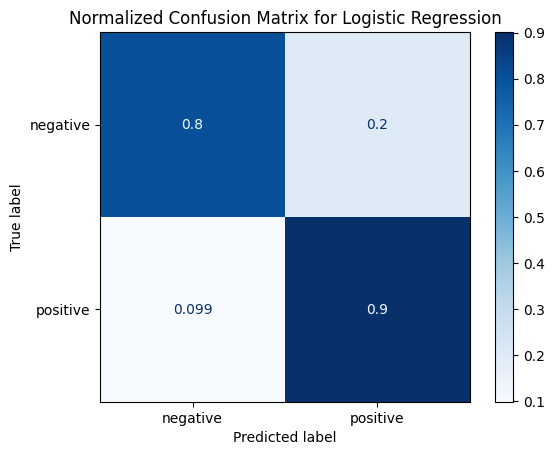

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Re-defining y_test and predicted for robustness
X_train, X_test, y_train, y_test = train_test_split(classify_data_df['content'], classify_data_df['review_category'], test_size = 0.2, random_state=123)

text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))
predicted = text_clf.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, predicted, labels=text_clf.classes_)

# Manually normalize the confusion matrix for display
# Normalize over the true labels (rows)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Display the normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=text_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Normalized Confusion Matrix for Logistic Regression')
plt.show()

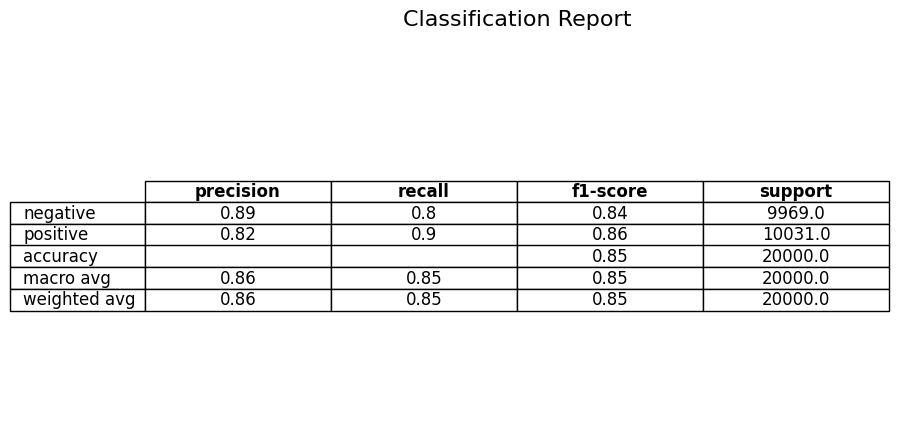

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# Re-defining y_test and predicted for robustness in case of out-of-order execution or kernel restart
# --- Start of included definitions from prior cells ---
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Assuming classify_data_df is defined from cell WABPMmWJ9tNW
# If classify_data_df is not defined, please run cell WABPMmWJ9tNW and its dependencies first.

X_train, X_test, y_train, y_test = train_test_split(classify_data_df['content'], classify_data_df['review_category'], test_size = 0.2, random_state=123)

text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))
predicted = text_clf.predict(X_test)
# --- End of included definitions ---

# Generate the classification report as a string
report_str = classification_report(y_test, predicted)

# A more robust way to parse the classification report from sklearn
report_data = classification_report(y_test, predicted, output_dict=True)
report_df = pd.DataFrame(report_data).transpose()

# Keep 'accuracy', 'macro avg', 'weighted avg' as requested
# report_df = report_df.drop(labels=['accuracy', 'macro avg', 'weighted avg'], errors='ignore') # This line is commented out to keep the rows

# Adjust the 'accuracy' row as per user request
report_df.loc['accuracy', ['precision', 'recall']] = np.nan # Set to NaN first
report_df.loc['accuracy', 'support'] = report_data['macro avg']['support'] # Set to total support

# Round numerical columns for better display
report_df = report_df.round(2)

# Convert NaN to empty strings for display in the table
report_df = report_df.fillna('')

# Create a Matplotlib figure and an axes object
fig, ax = plt.subplots(figsize=(8, 5)) # Increased figure size slightly to accommodate new rows

# Hide the axes
ax.axis('off')
ax.axis('tight')

# Create the table
table = ax.table(cellText=report_df.values,
                     colLabels=report_df.columns,
                     rowLabels=report_df.index,
                     cellLoc = 'center',
                     loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.3) # Increased vertical scale slightly

# Set column headers bold
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_text_props(weight='bold')

ax.set_title('Classification Report', fontsize=16, pad=20)

plt.show()

In [ ]:
# Random Forest Model
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn import metrics

text_clf_rf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                        ('rf', RandomForestClassifier(random_state=123)),
])
text_clf_rf.fit(X_train.astype('U'), y_train.astype('U'))
predicted_rf = text_clf_rf.predict(X_test)

In [ ]:
print(metrics.accuracy_score(y_test, predicted_rf))
print(classification_report(y_test, predicted_rf))

0.8464
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      9969
    positive       0.84      0.85      0.85     10031

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



In [ ]:
import pandas as pd

feature_names = text_clf_rf['vect'].get_feature_names_out()
importances = text_clf_rf['rf'].feature_importances_

# Create a Series for easier sorting and display
feature_importances_series = pd.Series(importances, index=feature_names)

# Sort the features by importance in descending order
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

# Print the top 20 most important features and their importances
print("Top 20 most important features in the Random Forest model:")
print(sorted_feature_importances.head(50))

Top 20 most important features in the Random Forest model:
good           0.026931
best           0.025008
love           0.023640
not            0.021390
to             0.020681
pay            0.019179
win            0.018371
the            0.018315
awesome        0.018150
bad            0.018074
worst          0.016993
fun            0.015142
great          0.015133
nice           0.014285
and            0.012118
update         0.012022
sucks          0.011292
game           0.010879
amazing        0.010604
cool           0.009259
money          0.009042
level          0.008714
it             0.008552
trash          0.008536
is             0.008256
hate           0.007852
in             0.007699
you            0.007076
no             0.007057
me             0.006788
this           0.006660
fix            0.006226
but            0.006072
they           0.005715
don            0.005671
unfair         0.005428
like           0.005357
of             0.005304
my             0.005303
match